In [40]:
import numpy as np
import matplotlib.pyplot as plt

from classy import Class
from scipy.interpolate import interp1d
from scipy.integrate import simpson

In [41]:
# ============================================================
# User options
# ============================================================

flag_save_plot = True

# Ly-alpha redshift bins used for the diagnostic
z_lya_list = [3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2]

# CLASS pk(k,z) uses k in 1/Mpc and returns P in Mpc^3
k_grid_1Mpc = np.logspace(-3, np.log10(5.0), 500)

# For now k_parallel is also in 1/Mpc.
# Later, BOSS k_parallel[s/km] should be converted to 1/Mpc.
kpar_grid_1Mpc = np.logspace(-2, np.log10(2.0), 120)

# Linear Ly-alpha effective parameters.
# For ratios, A cancels if kept the same for LCDM and monopoles.
A_lya = 1.0
beta_lya = 1.4

In [42]:
# ============================================================
# Base cosmology
# ============================================================


theta_s_100 = 1.04090
omega_b     = 0.02236
omega_cdm0  = 0.1202
tau_reio    = 0.0544
A_s         = np.exp(3.045) * 1e-10
n_s         = 0.9649

base_monopoles = {
    "theta_s_100": theta_s_100,
    # "h": h_fixed,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0*0.95,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,

    # we only need background; output can be minimal
    # (still keep tCl if you want consistency with previous runs)
    "output": "mPk",
    "non_linear": "none",
    "P_k_max_1/Mpc": 6.0,
    "z_pk": ",".join(str(z) for z in z_lya_list),


    # "output": "tCl,lCl",
    # "lensing": "yes",
    # "l_max_scalars": 2500,
    # "headers": "yes",
    # "format": "camb",   # optional, gives μK^2-style outputs
    # precision overrides
    # 'tol_background_integration': 1e-8,
    # 'background_integration_stepsize': 0.001,
    # 'background_Nloga': 2000000
    'background_Nloga': 400000

}

base = {
    "theta_s_100": theta_s_100,
    # "h": h_fixed,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,

    # we only need background; output can be minimal
    # (still keep tCl if you want consistency with previous runs)
    "output": "mPk",
    "non_linear": "none",
    "P_k_max_1/Mpc": 6.0,
    "z_pk": ",".join(str(z) for z in z_lya_list),

    'background_Nloga': 400000
}





In [43]:
# ============================================================
# Monopole benchmark models
# ============================================================

a_t = 1.0 / (40.0 + 1.0)
f_mon = 0.05

cases = [
    {
        "label": r"Intantenous",
        "color": "#0072B2",
        "ls": "-",
        "params": {
            "monopole_step_transition": "yes",
            "delta_mon_transition": 0.0001,
            "f_mon": f_mon,
            # "kappa_mon": 10.0,
            "a_t_mon": a_t,
        },
    },
    {
        "label": r"Intantenous",
        "color": "#D55E00",
        "ls": "--",
        "params": {
            "monopole_step_transition": "yes",
            "delta_mon_transition": 0.0001,
            "f_mon": f_mon,
            # "kappa_mon": 7.3077,
            "a_t_mon": 1/(1+3),
        },
    },
]

In [44]:
# ============================================================
# CLASS helper
# ============================================================

def compute_pklin_grid(
    base_params,
    k_grid_1Mpc,
    z_list,
    monopole_params=None,
    gauge="synchronous",
):
    """
    Compute linear P(k,z) for LCDM or monopoles.

    CLASS convention:
        pk_lin(k,z) expects k in 1/Mpc
        pk_lin(k,z) returns P in Mpc^3
    """

    cosmo = Class()

    settings = dict(base_params)
    settings["gauge"] = gauge
    settings["output"] = "mPk"
    settings["non_linear"] = "none"
    settings["P_k_max_1/Mpc"] = float(np.max(k_grid_1Mpc) * 1.2)
    settings["z_pk"] = ",".join(str(z) for z in z_list)

    if monopole_params is not None:
        settings.update(monopole_params)

    try:
        cosmo.set(settings)
        cosmo.compute()

        P_by_z = {}

        for z in z_list:
            P_by_z[z] = np.array([
                cosmo.pk_lin(float(k), float(z))
                for k in k_grid_1Mpc
            ])

        derived = {
            "h": cosmo.h(),
            "H0": 100.0 * cosmo.h(),
            "Omega_m": cosmo.Omega_m(),
            "sigma8": cosmo.sigma8(),
            "S8": cosmo.sigma8() * np.sqrt(cosmo.Omega_m() / 0.3),
        }

        return P_by_z, derived

    finally:
        try:
            cosmo.struct_cleanup()
        except Exception:
            pass
        try:
            cosmo.empty()
        except Exception:
            pass

In [45]:
# ============================================================
# Linear Ly-alpha 1D flux proxy
# ============================================================

def linear_flux_1d_from_Plin(
    k_grid_1Mpc,
    P_grid_Mpc3,
    kpar_grid_1Mpc,
    beta=1.4,
    A=1.0,
    kmax_1Mpc=None,
):
    """
    Linear effective Ly-alpha 1D flux power.

    Model:
        P_F^lin(k, mu, z)
        =
        A * (1 + beta * mu^2)^2 * P_lin(k,z)

    Projection:
        P_F^1D(k_parallel,z)
        =
        1/(2*pi) * integral_{k_parallel}^{kmax} k dk P_F(k,mu,z)

    where:
        mu = k_parallel / k

    This is a diagnostic proxy, not yet a full BOSS likelihood.
    """

    k_grid_1Mpc = np.asarray(k_grid_1Mpc)
    P_grid_Mpc3 = np.asarray(P_grid_Mpc3)
    kpar_grid_1Mpc = np.asarray(kpar_grid_1Mpc)

    if kmax_1Mpc is None:
        kmax_1Mpc = np.max(k_grid_1Mpc)

    valid = (
        np.isfinite(k_grid_1Mpc)
        & np.isfinite(P_grid_Mpc3)
        & (k_grid_1Mpc > 0.0)
        & (P_grid_Mpc3 > 0.0)
    )

    logP_interp = interp1d(
        np.log(k_grid_1Mpc[valid]),
        np.log(P_grid_Mpc3[valid]),
        kind="cubic",
        bounds_error=False,
        fill_value="extrapolate",
    )

    P1D = []

    for kpar in kpar_grid_1Mpc:
        if kpar <= 0.0 or kpar >= kmax_1Mpc:
            P1D.append(np.nan)
            continue

        k_int = np.logspace(
            np.log10(kpar),
            np.log10(kmax_1Mpc),
            1000,
        )

        P_int = np.exp(logP_interp(np.log(k_int)))

        mu = kpar / k_int
        flux_factor = A * (1.0 + beta * mu**2)**2

        integrand = k_int * flux_factor * P_int

        P1D_val = simpson(integrand, x=k_int) / (2.0 * np.pi)
        P1D.append(P1D_val)

    return np.asarray(P1D)

In [46]:
# ============================================================
# Compute LCDM
# ============================================================

P_lcdm_by_z, derived_lcdm = compute_pklin_grid(
    base_params=base,
    k_grid_1Mpc=k_grid_1Mpc,
    z_list=z_lya_list,
    monopole_params=None,
    gauge="synchronous",
)

print("=" * 80)
print("LCDM")
for key, value in derived_lcdm.items():
    print(f"{key:10s} = {value}")
print("=" * 80)


LCDM
h          = 0.6745590386717574
H0         = 67.45590386717573
Omega_m    = 0.31329809546222986
sigma8     = 0.8242975126481066
S8         = 0.8423687350094257


In [47]:
# ============================================================
# Compute monopole models
# ============================================================

models = []

for case in cases:
    P_mono_by_z, derived_mono = compute_pklin_grid(
        base_params=base_monopoles,
        k_grid_1Mpc=k_grid_1Mpc,
        z_list=z_lya_list,
        monopole_params=case["params"],
        gauge="synchronous",
    )

    models.append({
        "label": case["label"],
        "color": case["color"],
        "ls": case["ls"],
        "params": case["params"],
        "P_by_z": P_mono_by_z,
        "derived": derived_mono,
    })

    print(case["label"])
    print("params =", case["params"])
    for key, value in derived_mono.items():
        print(f"{key:10s} = {value}")
    print()


Intantenous
params = {'monopole_step_transition': 'yes', 'delta_mon_transition': 0.0001, 'f_mon': 0.05, 'a_t_mon': 0.024390243902439025}
h          = 0.713059757760699
H0         = 71.3059757760699
Omega_m    = 0.2685590858094321
sigma8     = 0.8125693338627821
S8         = 0.7688112429165197

Intantenous
params = {'monopole_step_transition': 'yes', 'delta_mon_transition': 0.0001, 'f_mon': 0.05, 'a_t_mon': 0.25}
h          = 0.6822901762215217
H0         = 68.22901762215217
Omega_m    = 0.2933279641164479
sigma8     = 0.8140489361091241
S8         = 0.8049457647613785



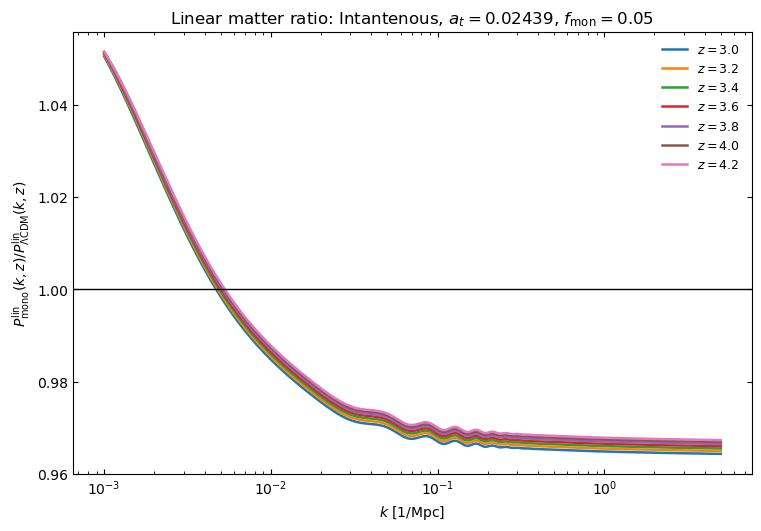

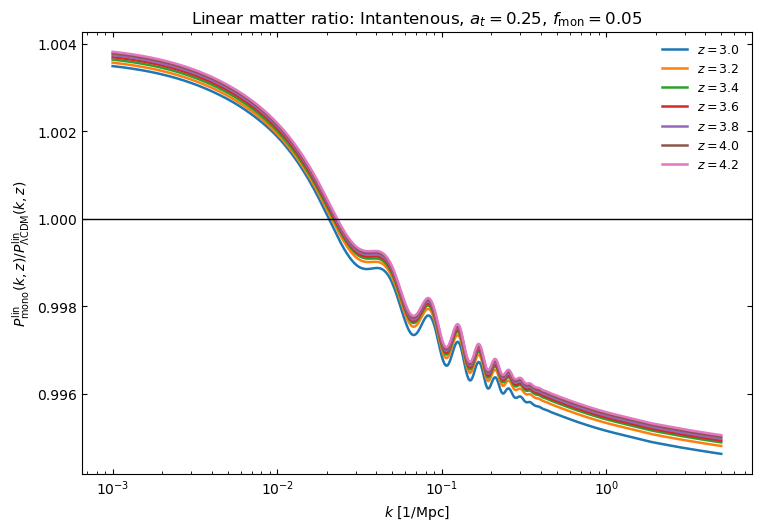

In [48]:
# ============================================================
# Plot 1: Linear matter power ratio
# ============================================================

for model in models:
    fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)

    for z in z_lya_list:
        P_lcdm = P_lcdm_by_z[z]
        P_mono = model["P_by_z"][z]

        valid = (
            np.isfinite(P_lcdm)
            & np.isfinite(P_mono)
            & (P_lcdm > 0.0)
        )

        ratio = P_mono[valid] / P_lcdm[valid]

        ax.plot(
            k_grid_1Mpc[valid],
            ratio,
            lw=1.8,
            label=rf"$z={z:.1f}$",
        )

    ax.axhline(1.0, color="black", lw=1.0)
    ax.set_xscale("log")
    ax.set_xlabel(r"$k\ [1/{\rm Mpc}]$")
    ax.set_ylabel(
        r"$P_{\rm mono}^{\rm lin}(k,z)"
        r"/P_{\Lambda{\rm CDM}}^{\rm lin}(k,z)$"
    )

    ax.set_title(
        rf"Linear matter ratio: {model['label']}, "
        rf"$a_t={model['params']['a_t_mon']:.4g}$, "
        rf"$f_{{\rm mon}}={model['params']['f_mon']}$"
    )

    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.legend(frameon=False, fontsize=9)

    if flag_save_plot:
        filename = (
            "linear_matter_ratio_"
            + model["label"].replace("$", "").replace("\\", "").replace("=", "")
            + ".pdf"
        )
        fig.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

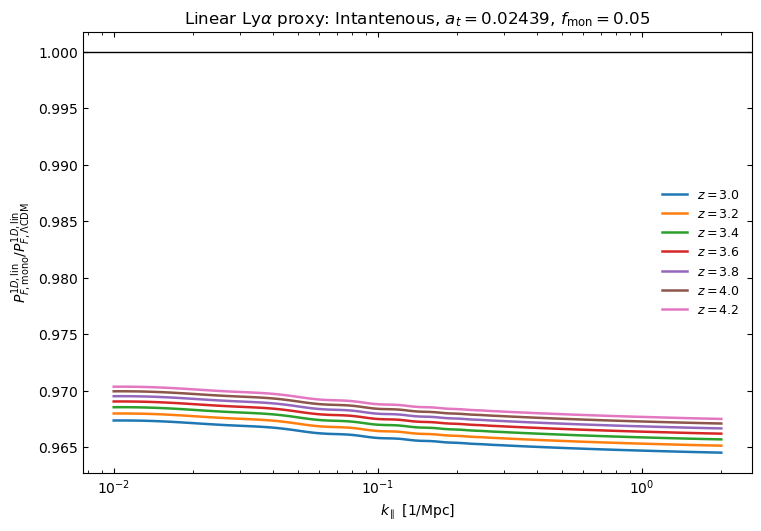

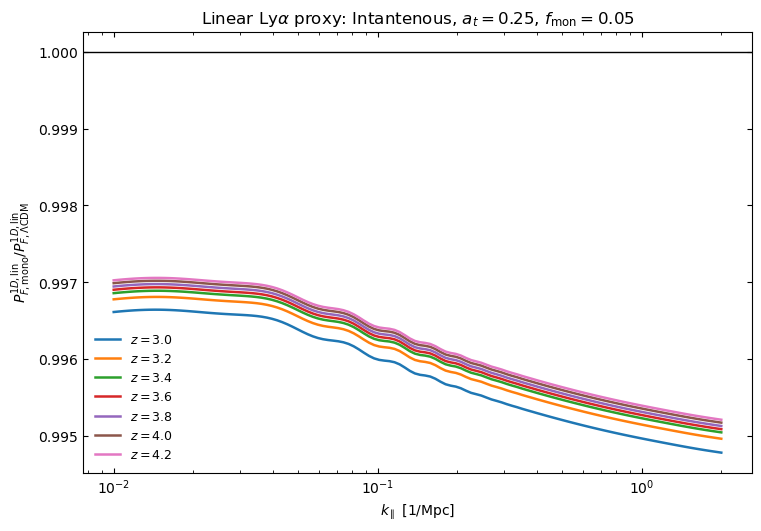

In [49]:
# ============================================================
# Plot 2: Linear Ly-alpha 1D flux proxy ratio
# ============================================================

for model in models:
    fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)

    for z in z_lya_list:
        P_lcdm = P_lcdm_by_z[z]
        P_mono = model["P_by_z"][z]

        PF1D_lcdm = linear_flux_1d_from_Plin(
            k_grid_1Mpc=k_grid_1Mpc,
            P_grid_Mpc3=P_lcdm,
            kpar_grid_1Mpc=kpar_grid_1Mpc,
            beta=beta_lya,
            A=A_lya,
            kmax_1Mpc=k_grid_1Mpc.max(),
        )

        PF1D_mono = linear_flux_1d_from_Plin(
            k_grid_1Mpc=k_grid_1Mpc,
            P_grid_Mpc3=P_mono,
            kpar_grid_1Mpc=kpar_grid_1Mpc,
            beta=beta_lya,
            A=A_lya,
            kmax_1Mpc=k_grid_1Mpc.max(),
        )

        valid = (
            np.isfinite(PF1D_lcdm)
            & np.isfinite(PF1D_mono)
            & (PF1D_lcdm > 0.0)
        )

        ratio = PF1D_mono[valid] / PF1D_lcdm[valid]

        ax.plot(
            kpar_grid_1Mpc[valid],
            ratio,
            lw=1.8,
            label=rf"$z={z:.1f}$",
        )

    ax.axhline(1.0, color="black", lw=1.0)
    ax.set_xscale("log")
    ax.set_xlabel(r"$k_\parallel\ [1/{\rm Mpc}]$")
    ax.set_ylabel(
        r"$P_{F,\rm mono}^{1D,\rm lin}"
        r"/P_{F,\Lambda{\rm CDM}}^{1D,\rm lin}$"
    )

    ax.set_title(
        rf"Linear Ly$\alpha$ proxy: {model['label']}, "
        rf"$a_t={model['params']['a_t_mon']:.4g}$, "
        rf"$f_{{\rm mon}}={model['params']['f_mon']}$"
    )

    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.legend(frameon=False, fontsize=9)

    if flag_save_plot:
        filename = (
            "linear_lya_flux_proxy_ratio_"
            + model["label"].replace("$", "").replace("\\", "").replace("=", "")
            + ".pdf"
        )
        fig.savefig(filename, bbox_inches="tight")
    else:
        plt.show()

In [50]:
def get_Hz_dict(base_params, z_list, monopole_params=None, gauge="synchronous"):
    """
    Return H(z) in km/s/Mpc for requested redshifts.
    """
    cosmo = Class()

    settings = dict(base_params)
    settings["gauge"] = gauge
    settings["output"] = "mPk"

    if monopole_params is not None:
        settings.update(monopole_params)

    cosmo.set(settings)
    cosmo.compute()

    Hz = {}
    for z in z_list:
        bg = cosmo.get_background()
        z_bg = np.asarray(bg["z"])
        H_bg = np.asarray(bg["H [1/Mpc]"])

        # interpolate H(z) in 1/Mpc
        H_1Mpc = np.interp(z, z_bg[::-1], H_bg[::-1])

        # convert 1/Mpc -> km/s/Mpc
        # H_class [1/Mpc] = H / c
        c_km_s = 299792.458
        Hz[z] = H_1Mpc * c_km_s

    try:
        cosmo.struct_cleanup()
    except Exception:
        pass
    try:
        cosmo.empty()
    except Exception:
        pass

    return Hz

In [51]:
kpar_skm = np.linspace(0.001, 0.02, 80)

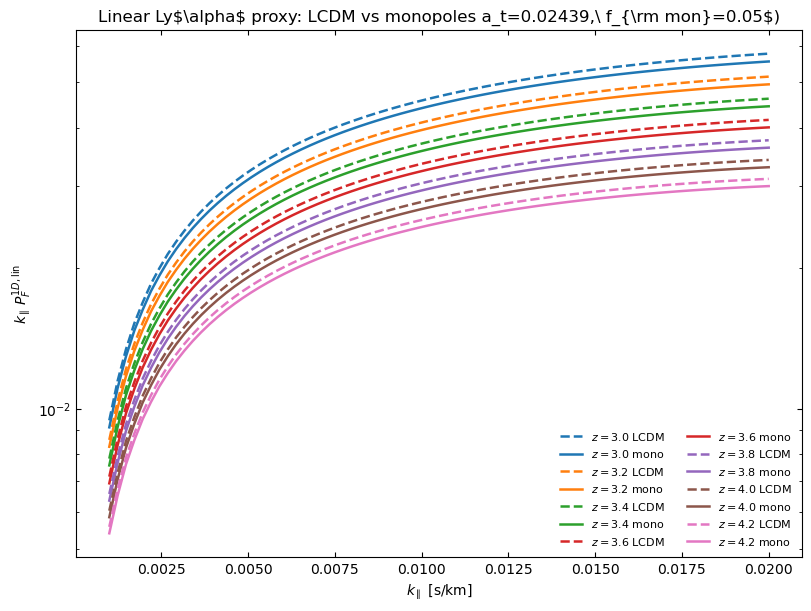

In [52]:
fig, ax = plt.subplots(figsize=(8.0, 6.0), constrained_layout=True)

# H(z) for LCDM
Hz_lcdm = get_Hz_dict(base, z_lya_list, monopole_params=None)

# choose one monopole model, e.g. first one
model = models[0]
Hz_mono = get_Hz_dict(base, z_lya_list, monopole_params=model["params"])

for i, z in enumerate(z_lya_list):
    color = plt.cm.tab10(i % 10)

    # Convert k_parallel [s/km] -> [1/Mpc]
    kpar_1Mpc_lcdm = kpar_skm * Hz_lcdm[z] / (1.0 + z)
    kpar_1Mpc_mono = kpar_skm * Hz_mono[z] / (1.0 + z)

    # Compute linear 1D flux proxy
    PF1D_lcdm = linear_flux_1d_from_Plin(
        k_grid_1Mpc=k_grid_1Mpc,
        P_grid_Mpc3=P_lcdm_by_z[z],
        kpar_grid_1Mpc=kpar_1Mpc_lcdm,
        beta=beta_lya,
        A=A_lya,
        kmax_1Mpc=k_grid_1Mpc.max(),
    )

    PF1D_mono = linear_flux_1d_from_Plin(
        k_grid_1Mpc=k_grid_1Mpc,
        P_grid_Mpc3=model["P_by_z"][z],
        kpar_grid_1Mpc=kpar_1Mpc_mono,
        beta=beta_lya,
        A=A_lya,
        kmax_1Mpc=k_grid_1Mpc.max(),
    )

    # Plot k_parallel * P_F^1D
    y_lcdm = kpar_skm * PF1D_lcdm
    y_mono = kpar_skm * PF1D_mono

    ax.plot(
        kpar_skm,
        y_lcdm,
        color=color,
        ls="--",
        lw=1.8,
        label=rf"$z={z:.1f}$ LCDM"
    )

    ax.plot(
        kpar_skm,
        y_mono,
        color=color,
        ls="-",
        lw=1.8,
        label=rf"$z={z:.1f}$ mono"
    )

ax.set_yscale("log")
ax.set_xlabel(r"$k_\parallel\ [{\rm s/km}]$")
ax.set_ylabel(r"$k_\parallel\,P_F^{1D,\rm lin}$")
ax.set_title(
    rf"Linear Ly$\alpha$ proxy: LCDM vs monopoles "
    # rf"($\kappa={model['params']['kappa_mon']},\ "
    rf"a_t={model['params']['a_t_mon']:.4g},\ "
    rf"f_{{\rm mon}}={model['params']['f_mon']}$)"
)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.legend(frameon=False, fontsize=8, ncol=2)

plt.show()

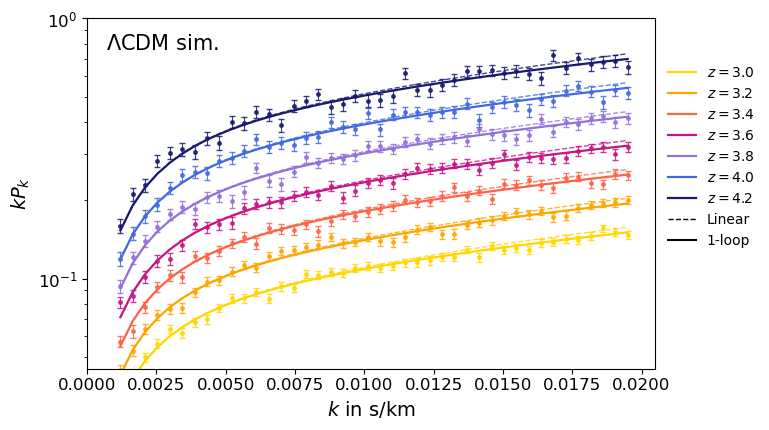

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# k range
# ------------------------------------------------------------
k = np.linspace(0.0012, 0.0195, 42)

# ------------------------------------------------------------
# Toy ΛCDM-like model for k P_k
# ------------------------------------------------------------
def linear_model(k, z):
    """
    Phenomenological linear curve.
    Tuned to give values closer to the reference plot:
    z=3.0 around 0.1--0.15,
    z=4.2 around 0.6--0.8.
    """

    # Stronger redshift-dependent amplitude
    A = 0.063 * np.exp(1.28 * (z - 3.0))

    # Fast rise at small k, then saturation
    shape = (1.0 - np.exp(-k / 0.0022))**0.85

    # Mild large-k tilt
    tilt = 1.0 + 1.5 * k / k.max()

    return A * shape * tilt


def one_loop_model(k, z):
    """
    Subtle one-loop correction.
    Slightly above linear, mostly visible at larger k.
    """

    lin = linear_model(k, z)

    correction = 1.0 - 0.045 * (k / k.max())**1.6

    return lin * correction


# ------------------------------------------------------------
# Redshifts and colors
# ------------------------------------------------------------
z_values = [3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2]

colors = [
    "gold",
    "orange",
    "tomato",
    "mediumvioletred",
    "mediumpurple",
    "royalblue",
    "midnightblue",
]

# ------------------------------------------------------------
# Mock data
# ------------------------------------------------------------
rng = np.random.default_rng(12)

mock_data = {}

for z in z_values:
    y_true = one_loop_model(k, z)

    # Relative errors: larger at low k and mildly larger at high z
    rel_err = 0.035 + 0.015 * (z - 3.0) + 0.015 * np.exp(-k / 0.003)

    yerr = y_true * rel_err
    yobs = rng.normal(y_true, yerr)

    mock_data[z] = {
        "y": yobs,
        "yerr": yerr,
    }


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.8, 4.4))

for z, color in zip(z_values, colors):

    # Data points
    ax.errorbar(
        k,
        mock_data[z]["y"],
        yerr=mock_data[z]["yerr"],
        fmt="o",
        ms=2.5,
        capsize=2,
        lw=0.8,
        color=color,
        alpha=0.85,
    )

    # Show both linear and one-loop for every z
    ax.plot(
        k,
        linear_model(k, z),
        ls="--",
        lw=1.0,
        color=color,
        alpha=0.8,
    )

    ax.plot(
        k,
        one_loop_model(k, z),
        ls="-",
        lw=1.6,
        color=color,
        label=fr"$z={z:.1f}$",
    )


# ------------------------------------------------------------
# Dummy legend entries for line styles
# ------------------------------------------------------------
ax.plot([], [], color="black", ls="--", lw=1.0, label="Linear")
ax.plot([], [], color="black", ls="-", lw=1.5, label="1-loop")

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
ax.set_yscale("log")

ax.set_xlim(0.0, 0.0205)
ax.set_ylim(0.045, 1.0)

ax.set_xlabel(r"$k$ in s/km", fontsize=14)
ax.set_ylabel(r"$k P_k$", fontsize=14)

ax.text(
    0.0007,
    0.80,
    r"$\Lambda$CDM sim.",
    fontsize=15,
    ha="left",
    va="center",
)

ax.tick_params(axis="both", which="major", labelsize=12)
ax.tick_params(axis="both", which="minor", labelsize=10)

ax.legend(
    fontsize=10,
    frameon=False,
    # loc="upper left",
    bbox_to_anchor=(1., 0.90),
)

plt.tight_layout()
plt.show()

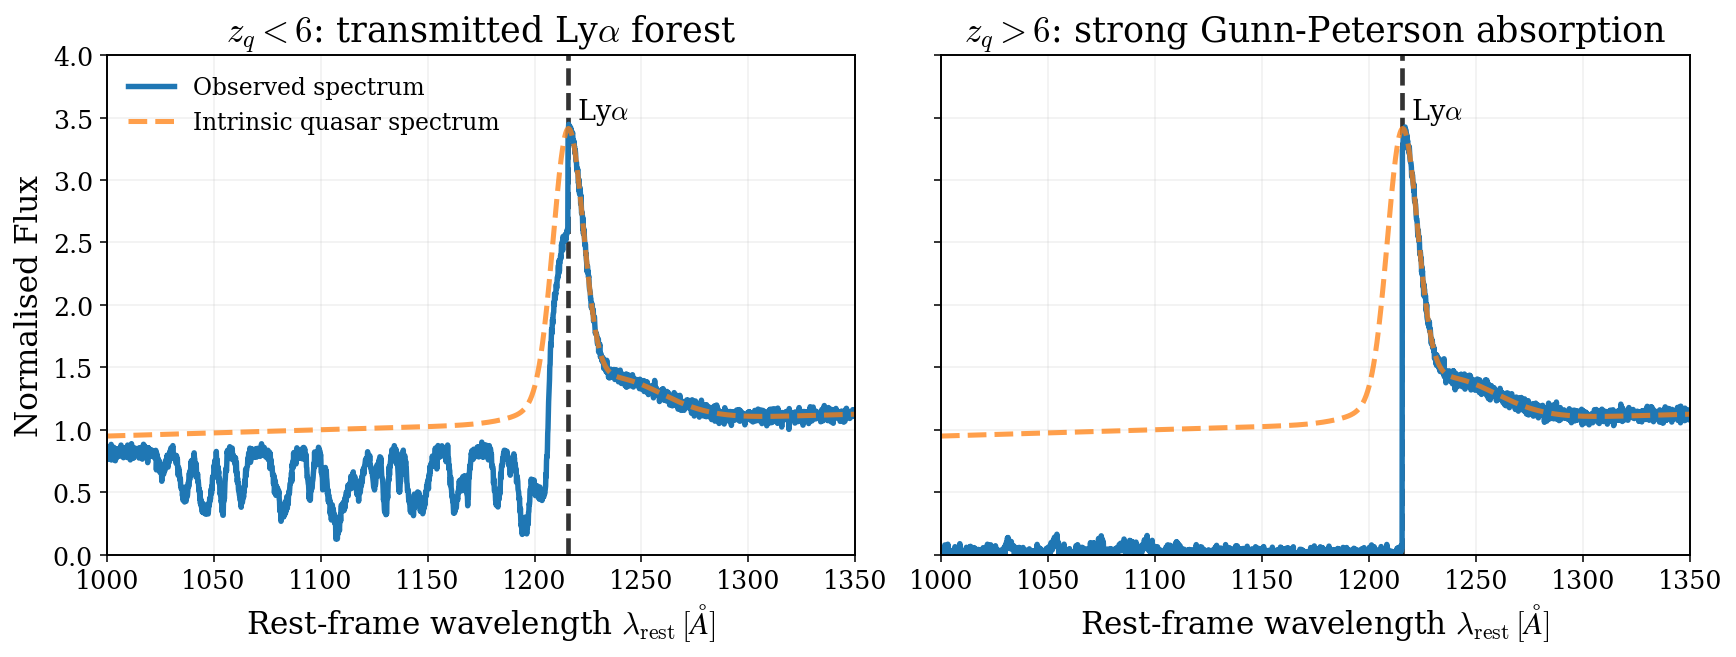

Saved:
  lya_reionization_demo_clean.pdf
  lya_reionization_demo_clean.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# Constants
# ==================================================
LYA = 1215.67  # Angstrom


# ==================================================
# Style for presentation plots
# ==================================================
def set_presentation_style(use_tex=False):
    """
    Set a cleaner presentation style for matplotlib plots.
    If use_tex=True, matplotlib will try to use LaTeX.
    """
    plt.rcParams.update({
        "figure.figsize": (12, 4.6),
        "figure.dpi": 140,
        "savefig.dpi": 250,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 12,
        "lines.linewidth": 2.0,
        "axes.linewidth": 1.0,
        "grid.alpha": 0.18,
        "grid.linewidth": 0.8,
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "text.usetex": use_tex,
    })


# ==================================================
# Intrinsic quasar spectrum
# ==================================================
def intrinsic_quasar_spectrum(lam_rest):
    continuum = 1.0 + 0.15 * (lam_rest - 1100.0) / 300.0
    lya_emission = 2.1 * np.exp(-0.5 * ((lam_rest - LYA) / 7.0) ** 2)
    red_wing = 0.35 * np.exp(-0.5 * ((lam_rest - 1235.0) / 24.0) ** 2)
    return continuum + lya_emission + red_wing


# ==================================================
# IGM transmission model
# ==================================================
def igm_transmission(lam_rest, z_q, regime="post_reionization", seed=1):
    rng = np.random.default_rng(seed)
    tau = np.zeros_like(lam_rest)

    forest = lam_rest < LYA
    z_abs = lam_rest / LYA * (1.0 + z_q) - 1.0

    if regime == "post_reionization":
        tau_eff = 0.18 * ((1.0 + z_abs) / 4.0) ** 3.0
        tau[forest] += tau_eff[forest]

        n_lines = 45
        centers = rng.uniform(1010.0, 1208.0, n_lines)
        widths = rng.uniform(0.5, 2.0, n_lines)
        depths = rng.uniform(0.12, 0.75, n_lines)

    elif regime == "near_reionization":
        tau_eff = 2.6 * ((1.0 + z_abs) / 7.0) ** 4.0
        tau[forest] += tau_eff[forest]

        n_lines = 90
        centers = rng.uniform(1000.0, 1212.0, n_lines)
        widths = rng.uniform(0.7, 3.0, n_lines)
        depths = rng.uniform(0.8, 2.8, n_lines)

        tau += 2.0 * np.exp(-0.5 * ((lam_rest - 1185.0) / 35.0) ** 2) * forest

    else:
        raise ValueError("regime must be 'post_reionization' or 'near_reionization'.")

    for c, w, d in zip(centers, widths, depths):
        tau += d * np.exp(-0.5 * ((lam_rest - c) / w) ** 2)

    return np.exp(-tau)


# ==================================================
# Mock spectrum
# ==================================================
def make_mock_spectrum(lam_rest, z_q, regime, seed=1, noise_level=0.035):
    rng = np.random.default_rng(seed)

    intrinsic = intrinsic_quasar_spectrum(lam_rest)
    transmission = igm_transmission(lam_rest, z_q, regime=regime, seed=seed)

    flux = intrinsic * transmission
    noise = rng.normal(0.0, noise_level, size=lam_rest.size)
    flux_noisy = np.clip(flux + noise, 0.0, None)

    return flux_noisy, intrinsic, transmission


# ==================================================
# Plotting
# ==================================================
def plot_lya_reionization_demo(output_dir=".", filename="lya_reionization_demo_clean",
                               use_tex=False):
    set_presentation_style(use_tex=use_tex)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    lam_rest = np.linspace(1000.0, 1350.0, 2500)

    # z < 6 example
    flux_lowz, intrinsic_lowz, _ = make_mock_spectrum(
        lam_rest,
        z_q=3.6,
        regime="post_reionization",
        seed=4,
        noise_level=0.03,
    )

    # z > 6 example
    flux_highz, intrinsic_highz, _ = make_mock_spectrum(
        lam_rest,
        z_q=6.3,
        regime="near_reionization",
        seed=9,
        noise_level=0.03,
    )

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)

    # ----------------------------------------------
    # Common formatting
    # ----------------------------------------------
    for ax in axes:
        ax.set_xlim(1000, 1350)
        ax.set_ylim(0, 4.0)
        ax.set_xlabel(r"Rest-frame wavelength $\lambda_{\rm rest}\,[\AA]$")
        ax.grid(True)

        # Ly-alpha marker
        ax.axvline(LYA, linestyle="--", linewidth=2.4, alpha=0.8, color="black")

        # cleaner spines
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

    axes[0].set_ylabel(r"Normalised Flux")

    # ----------------------------------------------
    # Left panel: z < 6
    # ----------------------------------------------
    axes[0].plot(
        lam_rest,
        flux_lowz,
        linewidth=2.8,
        label="Observed spectrum"
    )
    axes[0].plot(
        lam_rest,
        intrinsic_lowz,
        linestyle="--",
        linewidth=2.6,
        alpha=0.75,
        label="Intrinsic quasar spectrum"
    )
    axes[0].set_title(r"$z_q < 6$: transmitted Ly$\alpha$ forest")

    # ----------------------------------------------
    # Right panel: z > 6
    # ----------------------------------------------
    axes[1].plot(
        lam_rest,
        flux_highz,
        linewidth=2.8,
        label="Observed spectrum"
    )
    axes[1].plot(
        lam_rest,
        intrinsic_highz,
        linestyle="--",
        linewidth=2.6,
        alpha=0.75,
        label="Intrinsic quasar spectrum"
    )
    axes[1].set_title(r"$z_q > 6$: strong Gunn-Peterson absorption")

    # ----------------------------------------------
    # Ly-alpha labels
    # ----------------------------------------------
    for ax in axes:
        ax.text(
            LYA + 4,
            3.55,
            r"Ly$\alpha$",
            fontsize=14,
            va="center"
        )

    # One shared legend
    axes[0].legend(loc="upper left", frameon=False)

    fig.tight_layout()

    pdf_path = output_dir / f"{filename}.pdf"
    png_path = output_dir / f"{filename}.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    plt.show()

    print(f"Saved:\n  {pdf_path}\n  {png_path}")


if __name__ == "__main__":
    plot_lya_reionization_demo(
        output_dir=".",
        filename="lya_reionization_demo_clean",
        use_tex=False   # set True if your LaTeX setup in matplotlib works
    )


Candidates for 3.2 < z < 4.0:
plate  mjd  fiberID  run2d      ra       dec       z     class zWarning
----- ----- ------- ------- --------- --------- -------- ----- --------
 5010 55748     758 v5_13_2  239.1647 31.461089 3.999746   QSO        0
 5382 55982     476 v5_13_2 176.72212 8.0634151 3.999507   QSO        0
 8193 57333     757 v5_13_2 130.87527 59.710555  3.99948   QSO        0
 8060 57894     894 v5_13_2 243.12479 48.480062 3.999468   QSO        0
 5374 55947     108 v5_13_2 173.60026 7.3171122 3.999429   QSO        0
 5903 56064     182 v5_13_2 222.13223 18.792958 3.999379   QSO        0
 4842 55867     366 v5_13_2 122.50733 5.3267987 3.999122   QSO        0
 8500 57432     730 v5_13_2 213.49233 45.864885 3.999009   QSO        0
 8178 57428     963 v5_13_2 166.09104 57.321859 3.998868   QSO        0
 5779 56338     592 v5_13_2 137.13877  28.59447 3.998823   QSO        0
Trying candidate 1/50: z=4.000
Success: z=4.000, plate=5010, mjd=55748, fiber=758

Candidates for 7.0 < z

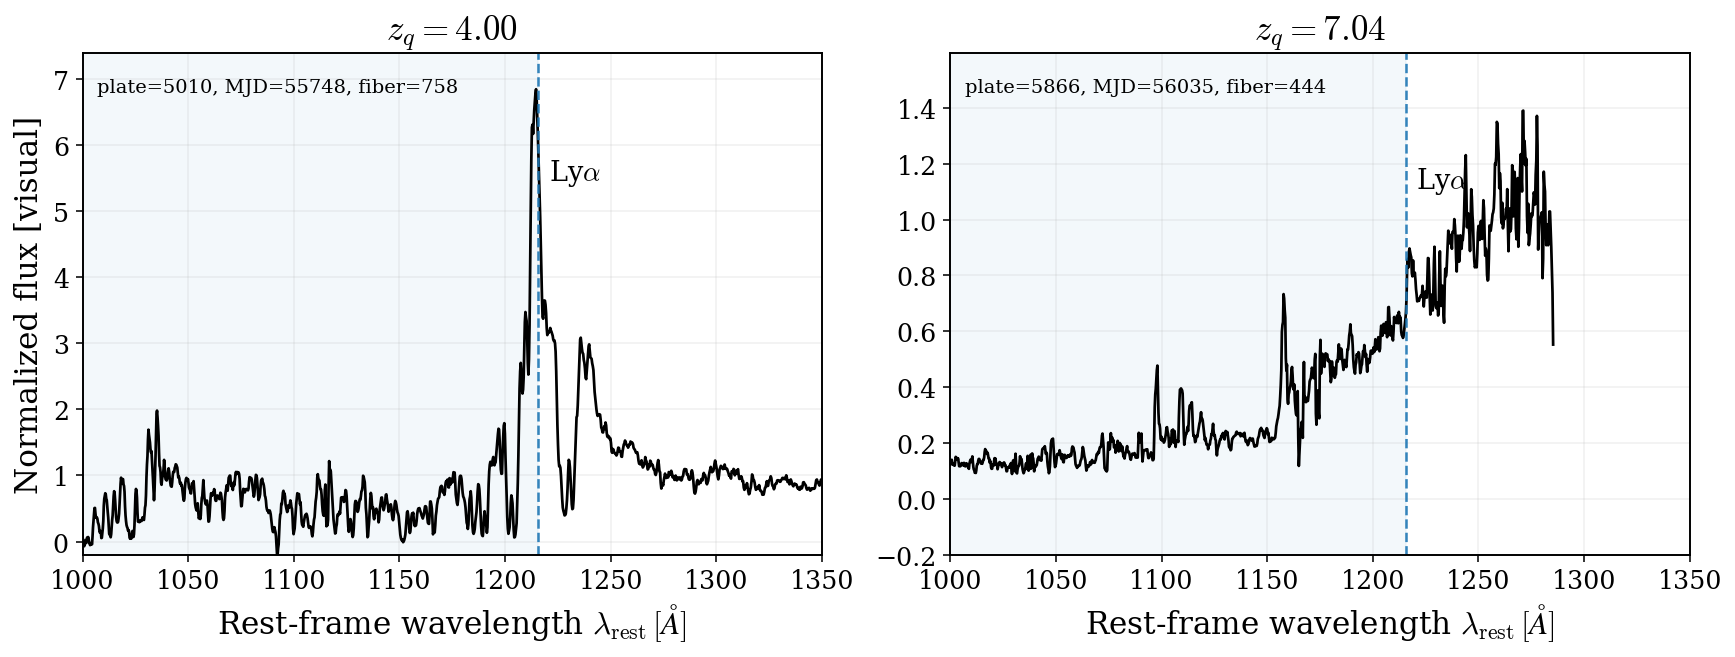

Saved: real_sdss_lya_examples.pdf
Saved: real_sdss_lya_examples.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astroquery.sdss import SDSS

LYA = 1215.67  # Angstrom


# ============================================================
# Search candidates
# ============================================================
def find_quasar_candidates(zmin, zmax, top=50, data_release=17):
    """
    Search SDSS SpecObj for QSO candidates.
    We request run2d because it is useful for spectra retrieval.
    """
    query = f"""
    SELECT TOP {top}
        plate, mjd, fiberID, run2d, ra, dec, z, class, zWarning
    FROM SpecObj
    WHERE
        class = 'QSO'
        AND z BETWEEN {zmin} AND {zmax}
        AND zWarning = 0
        AND plate IS NOT NULL
        AND mjd IS NOT NULL
        AND fiberID IS NOT NULL
    ORDER BY z DESC
    """

    return SDSS.query_sql(query, data_release=data_release)


# ============================================================
# Download spectrum robustly
# ============================================================
def try_download_spectrum(row, data_release=17):
    """
    Try to download one SDSS spectrum from a SpecObj row.
    Returns None if download fails.
    """
    plate = int(row["plate"])
    mjd = int(row["mjd"])
    fiber = int(row["fiberID"])

    try:
        spectra = SDSS.get_spectra(
            plate=plate,
            mjd=mjd,
            fiberID=fiber,
            data_release=data_release
        )

        if spectra is None or len(spectra) == 0:
            return None

        spec = spectra[0]
        data = spec[1].data

        lam_obs = 10 ** data["loglam"]
        flux = data["flux"]
        ivar = data["ivar"]

        return {
            "plate": plate,
            "mjd": mjd,
            "fiberID": fiber,
            "z": float(row["z"]),
            "ra": float(row["ra"]),
            "dec": float(row["dec"]),
            "lam_obs": lam_obs,
            "flux": flux,
            "ivar": ivar,
        }

    except Exception as err:
        print(f"Failed: plate={plate}, mjd={mjd}, fiber={fiber} | {err}")
        return None


def get_first_working_quasar(zmin, zmax, top=50, data_release=17):
    """
    Search candidates and try downloading spectra one by one.
    """
    candidates = find_quasar_candidates(zmin, zmax, top=top, data_release=data_release)

    if candidates is None or len(candidates) == 0:
        raise RuntimeError(f"No candidates found for {zmin} < z < {zmax}")

    print(f"\nCandidates for {zmin} < z < {zmax}:")
    print(candidates[:10])

    for i, row in enumerate(candidates):
        print(f"Trying candidate {i+1}/{len(candidates)}: z={row['z']:.3f}")
        spec = try_download_spectrum(row, data_release=data_release)
        if spec is not None:
            print(
                "Success:",
                f"z={spec['z']:.3f}, plate={spec['plate']}, "
                f"mjd={spec['mjd']}, fiber={spec['fiberID']}"
            )
            return spec, candidates

    raise RuntimeError(
        f"Found candidates for {zmin}<z<{zmax}, but none downloaded successfully."
    )


# ============================================================
# Prepare rest-frame spectrum
# ============================================================
def prepare_rest_frame(spec):
    z = spec["z"]
    lam_rest = spec["lam_obs"] / (1.0 + z)
    flux = spec["flux"]
    ivar = spec["ivar"]

    # Keep only finite pixels with non-zero weight
    mask = np.isfinite(lam_rest) & np.isfinite(flux) & np.isfinite(ivar)
    mask &= (ivar > 0)

    lam_rest = lam_rest[mask]
    flux = flux[mask]
    ivar = ivar[mask]

    return lam_rest, flux, ivar


# ============================================================
# Normalize for visual purposes
# ============================================================
def normalize_flux_for_plot(lam_rest, flux, norm_region=(1270, 1290)):
    """
    Simple visual normalization using the red side of Ly-alpha.
    This is NOT a physical continuum fit, just a plotting normalization.
    """
    mask = (lam_rest >= norm_region[0]) & (lam_rest <= norm_region[1])

    if np.sum(mask) > 10:
        norm = np.nanmedian(flux[mask])
    else:
        norm = np.nanmedian(flux[np.isfinite(flux)])

    if not np.isfinite(norm) or norm == 0:
        norm = 1.0

    return flux / norm


# ============================================================
# Mild smoothing for readability
# ============================================================
def smooth_flux(flux, window=7):
    """
    Mild moving-average smoothing.
    window should be odd and small.
    """
    if window <= 1:
        return flux

    kernel = np.ones(window) / window
    return np.convolve(flux, kernel, mode="same")


# ============================================================
# Optional clipping of extreme outliers for better display
# ============================================================
def clip_extreme_outliers(flux, low=-0.5, high=8.0):
    flux = np.copy(flux)
    flux[flux < low] = low
    flux[flux > high] = high
    return flux


def smooth_for_visual(lam, flux, window=7):
    """
    Very mild smoothing for slide readability.
    """
    if window <= 1:
        return flux
    kernel = np.ones(window) / window
    return np.convolve(flux, kernel, mode="same")


def plot_real_spectra_nicer(low_spec, high_spec,
                            output="real_sdss_lya_examples_better.pdf",
                            smooth_window_low=5,
                            smooth_window_high=7):
    """
    Plot two real quasar spectra in a more presentation-friendly way.
    """

    # --------------------------------------------------------
    # Matplotlib style
    # --------------------------------------------------------
    plt.rcParams.update({
        "figure.figsize": (12.5, 4.8),
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "axes.linewidth": 1.0,
        "grid.alpha": 0.18,
        "grid.linewidth": 0.8,
        "lines.linewidth": 1.8,
    })

    # --------------------------------------------------------
    # Prepare low-z spectrum
    # --------------------------------------------------------
    lam_low, flux_low, ivar_low = prepare_rest_frame(low_spec)
    flux_low = normalize_flux_for_plot(lam_low, flux_low, norm_region=(1270, 1290))
    flux_low = smooth_flux(flux_low, window=smooth_window_low)
    flux_low = clip_extreme_outliers(flux_low, low=-0.2, high=7.5)

    # --------------------------------------------------------
    # Prepare high-z spectrum
    # --------------------------------------------------------
    lam_high, flux_high, ivar_high = prepare_rest_frame(high_spec)
    flux_high = normalize_flux_for_plot(lam_high, flux_high, norm_region=(1270, 1290))
    flux_high = smooth_flux(flux_high, window=smooth_window_high)
    flux_high = clip_extreme_outliers(flux_high, low=-0.2, high=4.0)

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, sharey=False)

    # -------- LEFT PANEL: lower redshift --------
    ax = axes[0]
    ax.plot(lam_low, flux_low, color="black", lw=1.4)
    ax.axvline(LYA, ls="--", lw=1.3, color="tab:blue", alpha=0.9)

    # Shade forest region
    ax.axvspan(1000, LYA, color="tab:blue", alpha=0.05)

    ax.text(LYA + 5, 0.80 * np.nanmax(flux_low[(lam_low > 1000) & (lam_low < 1350)]),
            r"Ly$\alpha$", fontsize=14)

    ax.set_xlim(1000, 1350)
    ax.set_ylim(-0.2, max(2.6, 1.08*np.nanmax(flux_low)))
    ax.set_xlabel(r"Rest-frame wavelength $\lambda_{\rm rest}\,[\AA]$")
    ax.set_ylabel("Normalized flux [visual]")
    ax.set_title(rf"$z_q = {low_spec['z']:.2f}$")
    ax.grid(True)

    ax.text(
        0.02, 0.95,
        f"plate={low_spec['plate']}, MJD={low_spec['mjd']}, fiber={low_spec['fiberID']}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10
    )

    # -------- RIGHT PANEL: higher redshift --------
    ax = axes[1]
    ax.plot(lam_high, flux_high, color="black", lw=1.4)
    ax.axvline(LYA, ls="--", lw=1.3, color="tab:blue", alpha=0.9)

    ax.axvspan(1000, LYA, color="tab:blue", alpha=0.05)

    ax.text(LYA + 5, 0.80 * np.nanmax(flux_high[(lam_high > 1000) & (lam_high < 1350)]),
            r"Ly$\alpha$", fontsize=14)

    ax.set_xlim(1000, 1350)
    ax.set_ylim(-0.2, max(1.4, 1.10*np.nanmax(flux_high)))
    ax.set_xlabel(r"Rest-frame wavelength $\lambda_{\rm rest}\,[\AA]$")
    ax.set_title(rf"$z_q = {high_spec['z']:.2f}$")
    ax.grid(True)

    ax.text(
        0.02, 0.95,
        f"plate={high_spec['plate']}, MJD={high_spec['mjd']}, fiber={high_spec['fiberID']}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10
    )

    fig.tight_layout()
    fig.savefig(output, bbox_inches="tight")
    fig.savefig(output.replace(".pdf", ".png"), bbox_inches="tight")
    plt.show()

    print(f"Saved: {output}")
    print(f"Saved: {output.replace('.pdf', '.png')}")


# ============================================================
# Run
# ============================================================
if __name__ == "__main__":
    # Low-z quasar: SDSS/BOSS should usually find many.
    low_spec, low_candidates = get_first_working_quasar(
        zmin=3.2,
        zmax=4.0,
        top=50,
        data_release=17
    )

    # High-z quasars are rare and sometimes hard to retrieve via SDSS.get_spectra.
    # Start with a slightly broader range.
    high_spec, high_candidates = get_first_working_quasar(
        zmin=7.0,
        zmax=8.9,
        top=100,
        data_release=17
    )

    plot_real_spectra_nicer(
        low_spec,
        high_spec,
        output="real_sdss_lya_examples.pdf"
    )

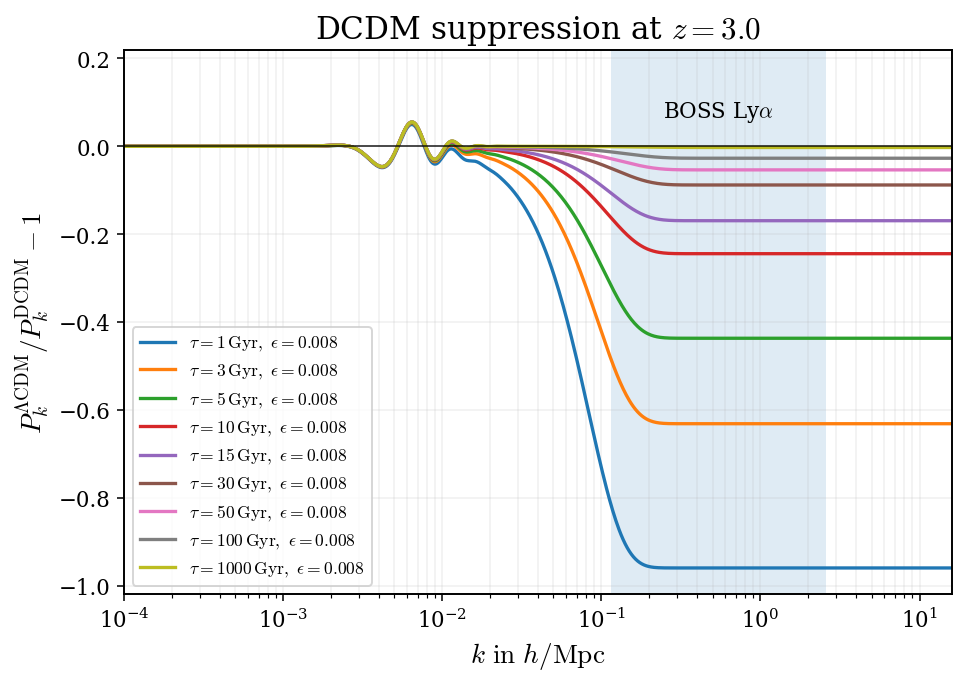

Saved:
  dcdm_family_eps_0p008_z_3p0.pdf
  dcdm_family_eps_0p008_z_3p0.png


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Basic cosmology
# ============================================================
h = 0.67
Omega_m = 0.315
Omega_L = 1.0 - Omega_m
n_s = 0.965


# ============================================================
# Helpers
# ============================================================
def H_z(z):
    """Hubble rate in km/s/Mpc."""
    H0 = 100.0 * h
    return H0 * np.sqrt(Omega_m * (1.0 + z)**3 + Omega_L)


def k_velocity_to_hmpc(k_vel, z):
    """
    Convert k in [s/km] to k in [h/Mpc].
    """
    return k_vel * H_z(z) / (1.0 + z) / h


def boss_lya_band(zmin=3.0, zmax=4.2, kvel_min=0.001, kvel_max=0.02):
    """
    Approximate BOSS Ly-alpha sensitivity window in h/Mpc,
    converted from a representative 1D flux-power range in s/km.
    """
    zs = np.linspace(zmin, zmax, 200)
    kmin = np.min(k_velocity_to_hmpc(kvel_min, zs))
    kmax = np.max(k_velocity_to_hmpc(kvel_max, zs))
    return kmin, kmax


def age_of_universe_approx(z, n=4000):
    """
    Approximate age of the Universe at redshift z in Gyr.
    Good enough for a toy DCDM presentation plot.
    """
    H0_inv_Gyr = 9.778 / h
    zp = np.linspace(z, 1.0e4, n)
    integrand = 1.0 / ((1.0 + zp) * np.sqrt(Omega_m * (1.0 + zp)**3 + Omega_L))
    return H0_inv_Gyr * np.trapz(integrand, zp)


# ============================================================
# Approximate LCDM linear power
# ============================================================
def transfer_BBKS(k_hmpc):
    """
    Simple BBKS transfer function for a presentation-level LCDM shape.
    """
    Gamma = Omega_m * h
    q = k_hmpc / Gamma

    L0 = np.log(1.0 + 2.34 * q) / (2.34 * q)
    C0 = (
        1.0
        + 3.89 * q
        + (16.1 * q)**2
        + (5.46 * q)**3
        + (6.71 * q)**4
    ) ** (-0.25)

    return L0 * C0


def growth_factor_approx(z):
    """
    Approximate linear growth factor normalized to D(0)=1.
    """
    def E2(x):
        return Omega_m * (1.0 + x)**3 + Omega_L

    def Omz(x):
        return Omega_m * (1.0 + x)**3 / E2(x)

    def Olz(x):
        return Omega_L / E2(x)

    def g(x):
        Om = Omz(x)
        Ol = Olz(x)
        return 5.0 * Om / (
            2.0 * (Om**(4.0 / 7.0) - Ol + (1.0 + Om / 2.0) * (1.0 + Ol / 70.0))
        )

    return (g(z) / (1.0 + z)) / g(0.0)


def lcdm_power_spectrum(k_hmpc, z):
    """
    Unnormalized LCDM linear power spectrum.
    For the ratio plot, absolute normalization is irrelevant.
    """
    T = transfer_BBKS(k_hmpc)
    D = growth_factor_approx(z)
    return k_hmpc**n_s * T**2 * D**2


# ============================================================
# Toy DCDM suppression model
# ============================================================
def dcdm_ratio_minus_one(k_hmpc, z, tau_Gyr=10.0, epsilon=3e-4):
    """
    Toy model for:
        P_DCDM / P_LCDM - 1

    This is NOT a Boltzmann-code result.
    It is only meant to generate a slide-quality qualitative plot.

    Parameters
    ----------
    tau_Gyr : float
        Decay lifetime in Gyr.
    epsilon : float
        Mass splitting / energy injection.
    """
    t_z = age_of_universe_approx(z)
    f_decayed = 1.0 - np.exp(-t_z / tau_Gyr)

    # Stronger epsilon -> stronger suppression
    # Shorter tau -> more decayed by redshift z
    amp = 1.15 * f_decayed * (epsilon / 0.008)**0.75
    amp = np.clip(amp, 0.0, 0.96)

    # Turnover scale:
    # larger epsilon -> stronger daughter kick -> suppression starts at lower k
    k_turn = 0.11 * (0.008 / max(epsilon, 1e-6))**0.45 * (tau_Gyr / 10.0)**0.12

    slope = 2.0
    suppression = 1.0 - np.exp(-(k_hmpc / k_turn)**slope)

    ratio_minus_one = -amp * suppression

    # Optional tiny wiggle on very large scales, only for visual similarity
    wiggle_center = 0.0055
    wiggle_width = 0.0010
    wiggle = 0.06 * np.exp(-0.5 * ((np.log10(k_hmpc) - np.log10(wiggle_center)) /
                                   (wiggle_width / wiggle_center))**2)
    ratio_minus_one += wiggle * np.sin(1200 * k_hmpc)

    return ratio_minus_one


def dcdm_power_spectrum(k_hmpc, z, tau_Gyr=10.0, epsilon=3e-4):
    P_lcdm = lcdm_power_spectrum(k_hmpc, z)
    Rm1 = dcdm_ratio_minus_one(k_hmpc, z, tau_Gyr=tau_Gyr, epsilon=epsilon)
    return P_lcdm * (1.0 + Rm1)


# ============================================================
# Plot function: one epsilon, many tau values
# ============================================================
def plot_dcdm_family(
    z=3.0,
    epsilon=3e-4,
    tau_list=(1, 3, 5, 10, 15, 30, 50, 100, 1000),
    output_dir=".",
    filename=None,
    show_boss_band=True
):
    """
    Produce a single-panel presentation plot:
    P_DCDM / P_LCDM - 1 vs k
    for one fixed epsilon and many tau values.
    """

    plt.rcParams.update({
        "figure.figsize": (7.0, 5.0),
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 9,
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "axes.linewidth": 1.0,
        "grid.alpha": 0.18,
        "grid.linewidth": 0.8,
    })

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if filename is None:
        filename = f"dcdm_ratio_eps_{epsilon:.4g}_z_{z:.1f}".replace(".", "p")

    k = np.logspace(-4, 1.2, 800)  # h/Mpc

    fig, ax = plt.subplots()

    # BOSS Ly-alpha band
    if show_boss_band:
        k_boss_min, k_boss_max = boss_lya_band(zmin=3.0, zmax=4.2)
        ax.axvspan(k_boss_min, k_boss_max, alpha=0.14)
        ax.text(
            np.sqrt(k_boss_min * k_boss_max),
            0.08,
            r"BOSS Ly$\alpha$",
            ha="center",
            va="center",
            fontsize=11
        )

    # Curves
    for tau in tau_list:
        y = dcdm_ratio_minus_one(k, z=z, tau_Gyr=tau, epsilon=epsilon)
        ax.semilogx(k, y, lw=1.7,
                    label=rf"$\tau={tau}\,\mathrm{{Gyr}},\ \epsilon={epsilon}$")

    ax.axhline(0.0, color="black", lw=1.0, alpha=0.7)

    ax.set_xlim(1e-4, 1.6e1)
    ax.set_ylim(-1.02, 0.22)
    ax.set_xlabel(r"$k\ \mathrm{in}\ h/\mathrm{Mpc}$")
    ax.set_ylabel(r"$P_k^{\Lambda \mathrm{CDM}}/P_k^{\mathrm{DCDM}} - 1$")
    # If you prefer the more standard ratio, replace the line above with:
    # ax.set_ylabel(r"$P_k^{\mathrm{DCDM}}/P_k^{\Lambda \mathrm{CDM}} - 1$")

    ax.grid(True, which="both")
    ax.legend(loc="lower left", frameon=True)
    ax.set_title(rf"DCDM suppression at $z={z:.1f}$")

    fig.tight_layout()

    pdf_path = output_dir / f"{filename}.pdf"
    png_path = output_dir / f"{filename}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    plt.show()

    print(f"Saved:\n  {pdf_path}\n  {png_path}")
    return pdf_path, png_path


# ============================================================
# Example run
# ============================================================
if __name__ == "__main__":
    plot_dcdm_family(
        z=3.0,
        epsilon=0.008,
        tau_list=(1, 3, 5, 10, 15, 30, 50, 100, 1000),
        output_dir=".",
        filename="dcdm_family_eps_0p008_z_3p0"
    )